# MMIDNet Pipeline: Human Identification from Point Clouds

**Proof-of-Concept (POC) Implementation**

This notebook demonstrates human identification using point cloud data, implementing the MMIDNet architecture from the research paper. Since real mmWave radar data is not publicly available, we use the MPI-FAUST 3D mesh dataset to generate synthetic radar-like point cloud sequences.

**Pipeline Overview:**
- Data preparation: Load PLY files, apply FPS sampling, generate temporal sequences
- Preprocessing: Simulate radar characteristics (velocity, SNR, noise)
- Model training: MMIDNet architecture with mixed precision
- Evaluation: Standard and sliding window evaluation with metrics

**Key Features:**
- Farthest Point Sampling (FPS) for shape preservation
- Subject-specific characteristics (body scale, walking speed, SNR)
- Full MMIDNet architecture (T-Net, Residual CNN, Bi-LSTM)
- Comprehensive evaluation and visualization


In [1]:
# ============================================================================
# ENVIRONMENT SETUP: Works on both Google Colab and Local
# ============================================================================

import os
import sys

# Check if running on Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("✓ Running on Google Colab")
except ImportError:
    IN_COLAB = False
    print("✓ Running locally")

if IN_COLAB:
    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive')

    # Set base path to your project folder in Drive
    # Adjust this path to match where you uploaded your files
    DRIVE_PROJECT_PATH = '/content/drive/MyDrive/Arqaios'  # Update if different

    # Change to project directory
    os.chdir(DRIVE_PROJECT_PATH)
    print(f"Working directory: {os.getcwd()}")

    # Install requirements
    if os.path.exists('requirements.txt'):
        print("✓ Found requirements.txt")
        # Upgrade pip first (use os.system for compatibility)
        os.system('pip install --upgrade pip -q')
        # Install from requirements.txt
        os.system('pip install -r requirements.txt -q')
        print("✓ All packages installed from requirements.txt")
    else:
        print("✗ requirements.txt not found!")
        print(f"  Looking in: {os.getcwd()}")
else:
    # Local environment - use current directory or parent
    
    if os.path.basename(os.getcwd()) == 'notebooks':
        DRIVE_PROJECT_PATH = os.path.dirname(os.getcwd())
        os.chdir(DRIVE_PROJECT_PATH)
    else:
        DRIVE_PROJECT_PATH = os.getcwd()
    print(f"Working directory: {os.getcwd()}")

# Add src to Python path
sys.path.insert(0, os.path.join(DRIVE_PROJECT_PATH, 'src'))

# Verify GPU availability
import tensorflow as tf
print("\n" + "="*60)
print("GPU CHECK")
print("="*60)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")
if tf.config.list_physical_devices('GPU'):
    print(f"GPU Device: {tf.config.list_physical_devices('GPU')[0]}")
    # Set memory growth to avoid allocating all GPU memory at once
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            print("GPU memory growth enabled")
        except RuntimeError as e:
            print(f"GPU memory growth error: {e}")
else:
    print("⚠️  WARNING: No GPU detected! Enable GPU in Runtime > Change runtime type")
print("="*60 + "\n")

✓ Running on Google Colab
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Arqaios
✓ Found requirements.txt
✓ All packages installed from requirements.txt

GPU CHECK
TensorFlow version: 2.19.0
GPU Available: True
GPU Device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU memory growth enabled



In [2]:
# Set up paths (works for both Colab and local)
if IN_COLAB:
    # Use absolute paths for Colab
    checkpoint_dir = os.path.join(DRIVE_PROJECT_PATH, 'checkpoints')
    results_dir = os.path.join(DRIVE_PROJECT_PATH, 'results')
else:
    # Use relative paths for local
    checkpoint_dir = 'checkpoints'
    results_dir = 'results'

# Create directories
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

print(f"Checkpoints will be saved to: {checkpoint_dir}")
print(f"Results will be saved to: {results_dir}")

Checkpoints will be saved to: /content/drive/MyDrive/Arqaios/checkpoints
Results will be saved to: /content/drive/MyDrive/Arqaios/results


In [3]:
# Import libraries for visualization
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import pickle
import sys
import os
import gc
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import mixed_precision
from tensorflow.keras.mixed_precision import LossScaleOptimizer
from sklearn.metrics import confusion_matrix

# Import our modules
from src.data_utils import load_ply_file, generate_dataset, create_temporal_sequence
from src.model import build_mmidnet
from src.train import train_model, split_dataset_by_subject, setup_callbacks
from src.evaluate import evaluate_model, evaluate_with_sliding_window, get_per_class_accuracy
from tensorflow.keras.utils import to_categorical

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


## Phase 1: Data Preparation & Visualization


✓ Data path found: /content/drive/MyDrive/Arqaios/MPI-FAUST/training/scans
  Files: 100 PLY files


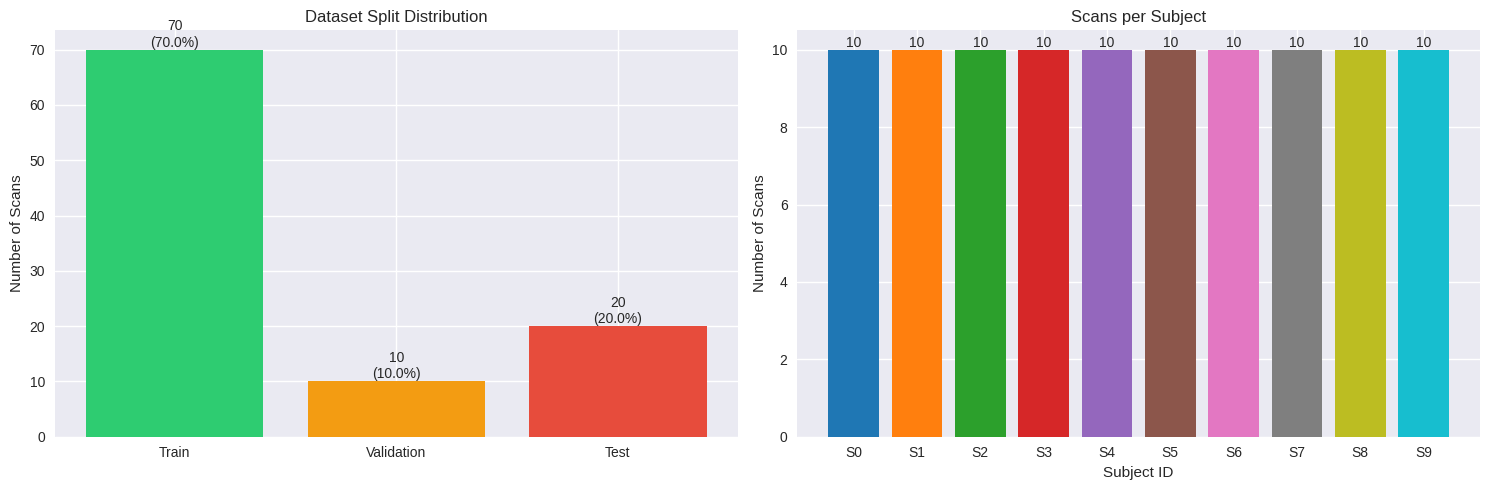

Train: 70 scans
Val: 10 scans
Test: 20 scans


In [4]:
# Dataset configuration (uses DRIVE_PROJECT_PATH from cell 1)
# Dataset paths (relative to project root)
scans_dir = os.path.join(DRIVE_PROJECT_PATH, 'MPI-FAUST/training/scans')
num_subjects = 10
scans_per_subject = 10
total_scans = 100

# Verify data path exists
if os.path.exists(scans_dir):
    print(f"✓ Data path found: {scans_dir}")
    print(f"  Files: {len([f for f in os.listdir(scans_dir) if f.endswith('.ply')])} PLY files")
else:
    print(f"✗ ERROR: Data path not found: {scans_dir}")
    print("  Please check your Drive path and folder structure")

# Split dataset
train_scans, val_scans, test_scans = split_dataset_by_subject(
    num_subjects=num_subjects,
    scans_per_subject=scans_per_subject,
    train_ratio=0.7,
    val_ratio=0.1,
    test_ratio=0.2
)

# Visualize split
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Split distribution
split_counts = [len(train_scans), len(val_scans), len(test_scans)]
split_labels = ['Train', 'Validation', 'Test']
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[0].bar(split_labels, split_counts, color=colors)
axes[0].set_ylabel('Number of Scans')
axes[0].set_title('Dataset Split Distribution')
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({height/total_scans*100:.1f}%)',
                ha='center', va='bottom')

# Subject distribution
scans_by_subject = {}
for scan_idx in range(total_scans):
    subject_id = scan_idx // scans_per_subject
    if subject_id not in scans_by_subject:
        scans_by_subject[subject_id] = []
    scans_by_subject[subject_id].append(scan_idx)

subject_counts = [len(scans_by_subject[i]) for i in range(num_subjects)]
bars = axes[1].bar(range(num_subjects), subject_counts, color=plt.cm.tab10(range(num_subjects)))
axes[1].set_xlabel('Subject ID')
axes[1].set_ylabel('Number of Scans')
axes[1].set_title('Scans per Subject')
axes[1].set_xticks(range(num_subjects))
axes[1].set_xticklabels([f'S{i}' for i in range(num_subjects)])
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Train: {len(train_scans)} scans")
print(f"Val: {len(val_scans)} scans")
print(f"Test: {len(test_scans)} scans")


### Visualize Sample Point Cloud


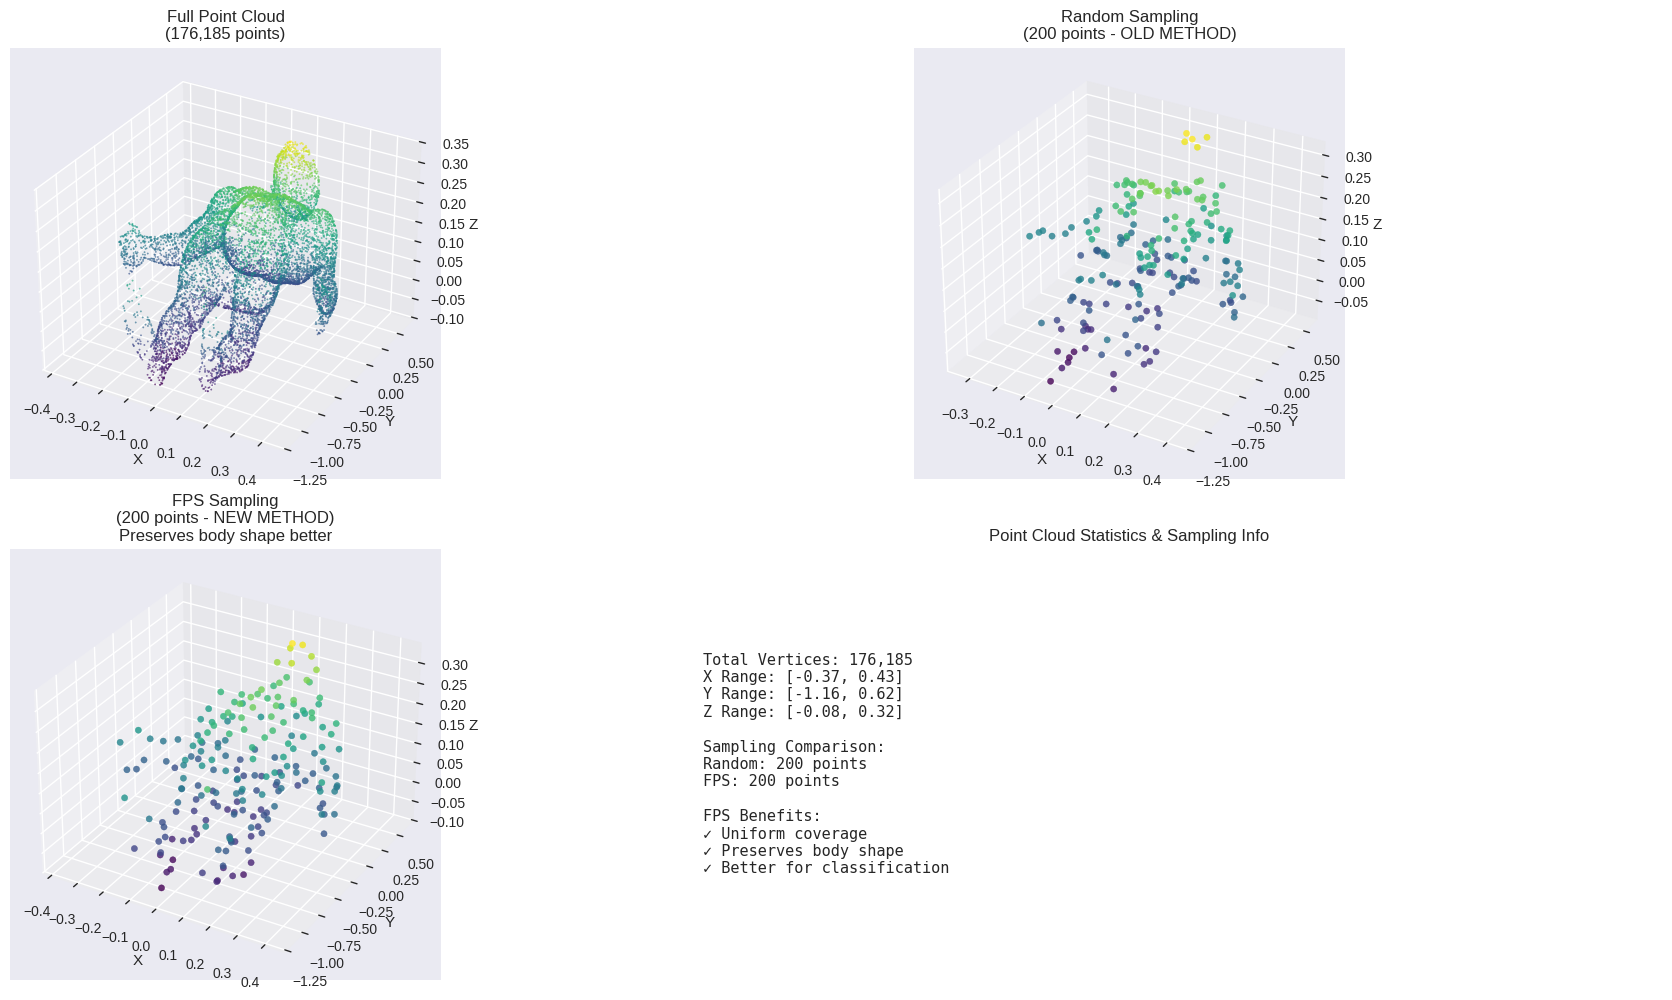


Sampling Method Comparison:
Random Sampling: Points selected randomly - may miss important body features
FPS Sampling: Points selected to maximize coverage - preserves body proportions


In [5]:
# Load and visualize a sample scan
from src.data_utils import farthest_point_sampling

test_scan_path = f'{scans_dir}/tr_scan_000.ply'
test_vertices = load_ply_file(test_scan_path)

fig = plt.figure(figsize=(20, 10))

# Full point cloud (for reference)
ax1 = fig.add_subplot(221, projection='3d')
sample_indices = np.random.choice(len(test_vertices), min(10000, len(test_vertices)), replace=False)
ax1.scatter(test_vertices[sample_indices, 0],
           test_vertices[sample_indices, 1],
           test_vertices[sample_indices, 2],
           c=test_vertices[sample_indices, 2], cmap='viridis', s=1, alpha=0.6)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_title(f'Full Point Cloud\n({len(test_vertices):,} points)')

# Random Sampling (200 points)
ax2 = fig.add_subplot(222, projection='3d')
np.random.seed(42)
random_sampled = test_vertices[np.random.choice(len(test_vertices), 200, replace=False)]
ax2.scatter(random_sampled[:, 0], random_sampled[:, 1], random_sampled[:, 2],
           c=random_sampled[:, 2], cmap='viridis', s=20, alpha=0.8)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_title('Random Sampling\n(200 points)')

# FPS Sampling (200 points)
ax3 = fig.add_subplot(223, projection='3d')
fps_sampled, fps_indices = farthest_point_sampling(test_vertices, 200)
ax3.scatter(fps_sampled[:, 0], fps_sampled[:, 1], fps_sampled[:, 2],
           c=fps_sampled[:, 2], cmap='viridis', s=20, alpha=0.8)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_title('FPS Sampling\n(200 points)\nPreserves body shape')

# Statistics
ax4 = fig.add_subplot(224)
stats_text = [
    f'Total Vertices: {len(test_vertices):,}',
    f'X Range: [{test_vertices[:, 0].min():.2f}, {test_vertices[:, 0].max():.2f}]',
    f'Y Range: [{test_vertices[:, 1].min():.2f}, {test_vertices[:, 1].max():.2f}]',
    f'Z Range: [{test_vertices[:, 2].min():.2f}, {test_vertices[:, 2].max():.2f}]',
    '',
    'Sampling Comparison:',
    f'Random: {len(random_sampled)} points',
    f'FPS: {len(fps_sampled)} points',
    '',
    'FPS Benefits:',
    '✓ Uniform coverage',
    '✓ Preserves body shape',
    '✓ Better for classification'
]
ax4.axis('off')
ax4.text(0.1, 0.5, '\n'.join(stats_text),
        fontsize=11, verticalalignment='center', family='monospace')
ax4.set_title('Point Cloud Statistics')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("Sampling Method Comparison:")
print("="*60)
print("Random Sampling: Points selected randomly - may miss important body features")
print("FPS Sampling: Points selected to maximize coverage - preserves body proportions")
print("="*60)


### Visualize Temporal Sequence Generation


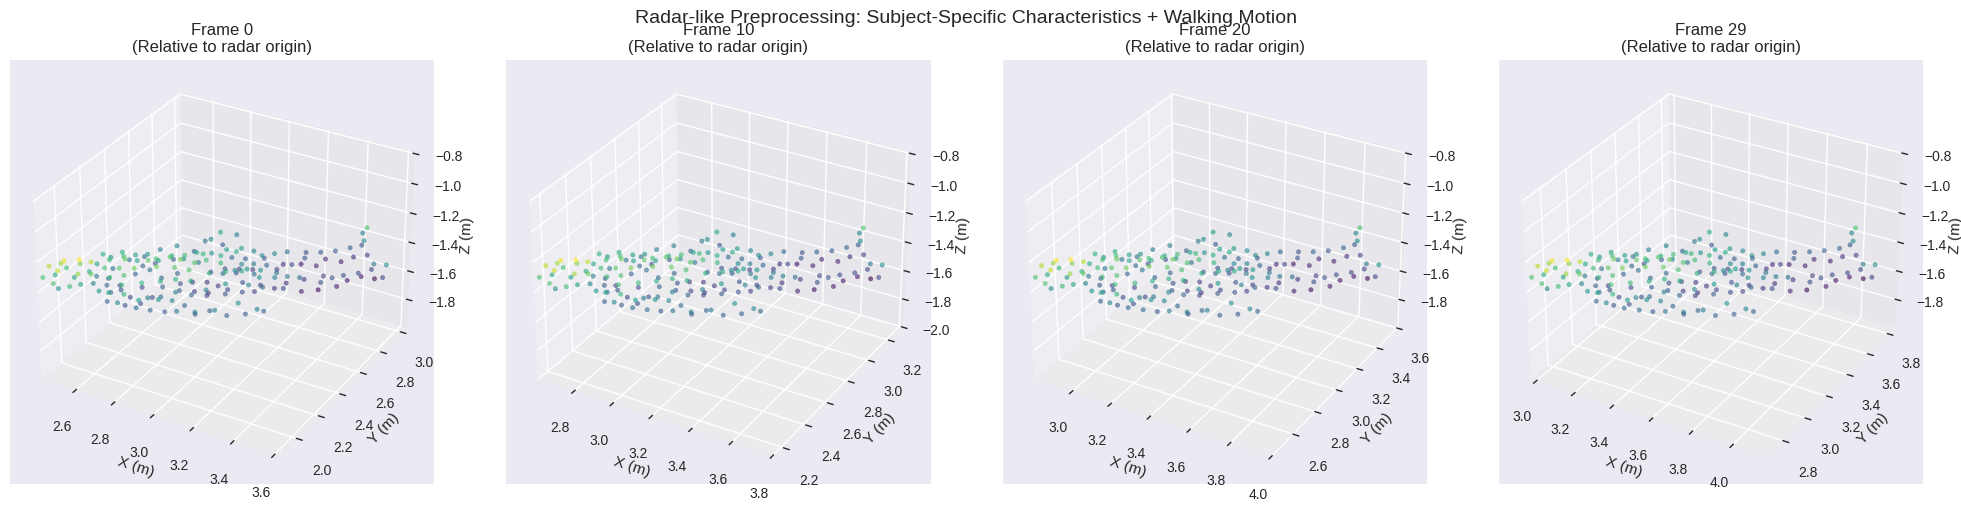

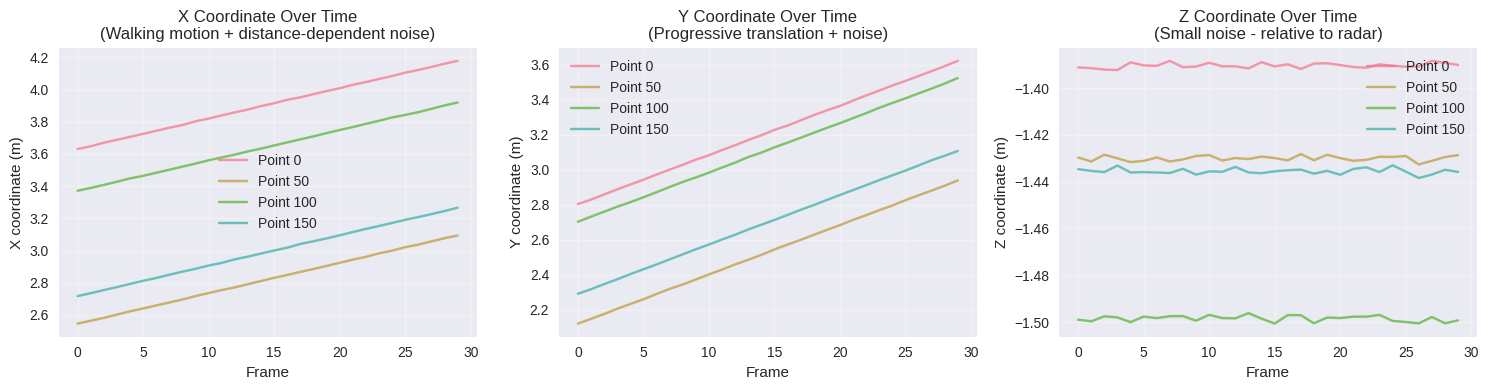

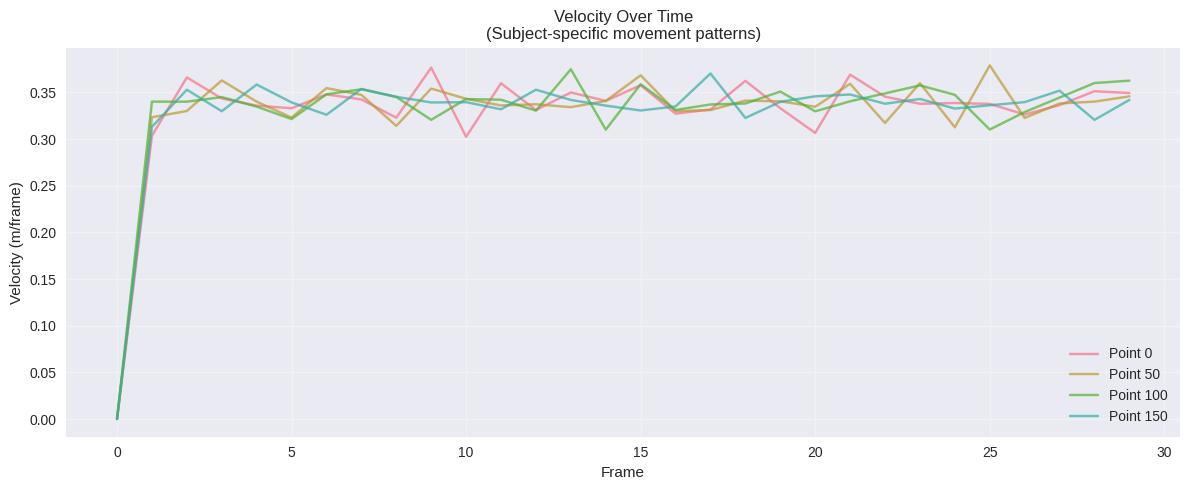

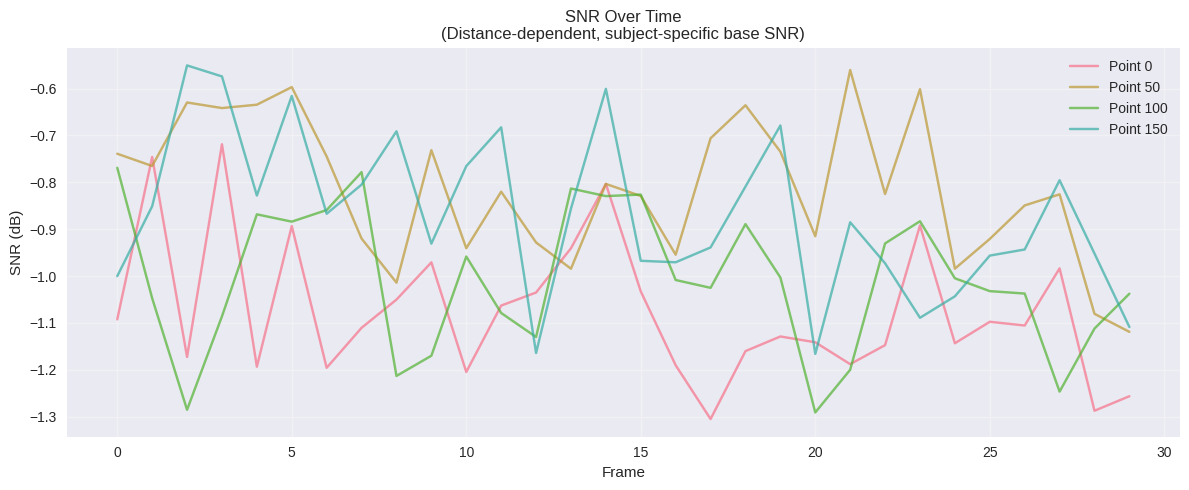

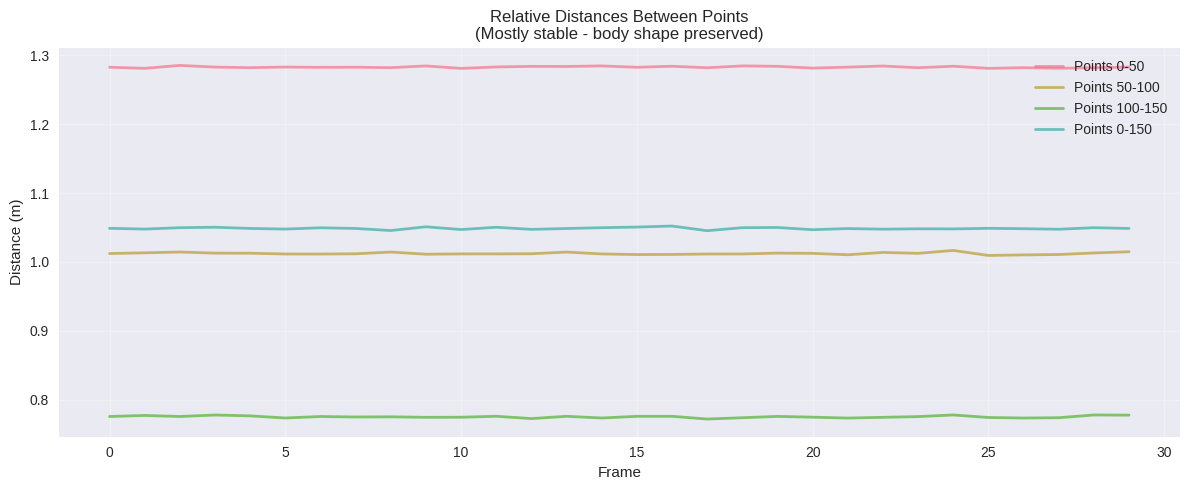


NEW Preprocessing Characteristics (Radar-like + Subject-Specific):
✓ Farthest Point Sampling (FPS) - preserves body shape better than random
✓ Deterministic sampling per subject (same subject → similar points)
✓ Same points sampled once per sequence (preserves rigid transformation)
✓ Subject-specific body scale applied
✓ Random rotation (0-360°) applied once
✓ Random translation (0-3m) on x,y axes only
✓ Coordinates transformed relative to radar origin (0, 0, 1.5m)
✓ Subject-specific walking speed: 0.025-0.040 m/frame
✓ Progressive translation per frame (walking motion)
✓ Distance-dependent noise (farther = more noise, like radar)
✓ Subject-specific movement consistency: 0.85
✓ Velocity channel computed (frame-to-frame position change)
✓ Subject-specific base SNR: 20.0 dB
✓ SNR decreases with distance (~2dB/meter, typical radar)
✓ Relative distances mostly preserved (body shape maintained)
✓ Output: (30, 200, 5) - channels: (x, y, z, velocity, snr)


In [ ]:
# Visualize NEW preprocessing approach (radar-like with subject-specific characteristics)

test_sequence, test_label = create_temporal_sequence(
    test_vertices, num_frames=30, num_points=200,
    subject_id=0, augment=True, random_seed=42
)

# Visualize frames (xyz coordinates)
fig = plt.figure(figsize=(20, 5))
frame_indices = [0, 10, 20, 29]

for i, frame_idx in enumerate(frame_indices):
    ax = fig.add_subplot(1, 4, i+1, projection='3d')
    frame_xyz = test_sequence[frame_idx, :, :3]  # Extract xyz (first 3 channels)
    
    ax.scatter(frame_xyz[:, 0], frame_xyz[:, 1], frame_xyz[:, 2],
              c=frame_xyz[:, 2], cmap='viridis', s=10, alpha=0.6)
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title(f'Frame {frame_idx}\n(Relative to radar origin)')
    
    # Set equal aspect ratio
    max_range = np.array([frame_xyz[:, 0].max() - frame_xyz[:, 0].min(),
                          frame_xyz[:, 1].max() - frame_xyz[:, 1].min(),
                          frame_xyz[:, 2].max() - frame_xyz[:, 2].min()]).max() / 2.0
    mid_x = (frame_xyz[:, 0].max() + frame_xyz[:, 0].min()) * 0.5
    mid_y = (frame_xyz[:, 1].max() + frame_xyz[:, 1].min()) * 0.5
    mid_z = (frame_xyz[:, 2].max() + frame_xyz[:, 2].min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

plt.suptitle('Radar-like Preprocessing: Subject-Specific Characteristics + Walking Motion', fontsize=14)
plt.tight_layout()
plt.show()

# Show point trajectories (xyz coordinates)
point_indices = [0, 50, 100, 150]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for point_idx in point_indices:
    point_trajectory = test_sequence[:, point_idx, :3]  # xyz only
    axes[0].plot(point_trajectory[:, 0], label=f'Point {point_idx}', alpha=0.7)
    axes[1].plot(point_trajectory[:, 1], label=f'Point {point_idx}', alpha=0.7)
    axes[2].plot(point_trajectory[:, 2], label=f'Point {point_idx}', alpha=0.7)

axes[0].set_xlabel('Frame')
axes[0].set_ylabel('X coordinate (m)')
axes[0].set_title('X Coordinate Over Time\n(Walking motion + distance-dependent noise)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Frame')
axes[1].set_ylabel('Y coordinate (m)')
axes[1].set_title('Y Coordinate Over Time\n(Progressive translation + noise)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Frame')
axes[2].set_ylabel('Z coordinate (m)')
axes[2].set_title('Z Coordinate Over Time\n(Small noise - relative to radar)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# NEW: Visualize velocity channel
fig, ax = plt.subplots(figsize=(12, 5))
for point_idx in point_indices:
    velocity = test_sequence[:, point_idx, 3]  # 4th channel = velocity
    ax.plot(velocity, label=f'Point {point_idx}', alpha=0.7)

ax.set_xlabel('Frame')
ax.set_ylabel('Velocity (m/frame)')
ax.set_title('Velocity Over Time\n(Subject-specific movement patterns)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# NEW: Visualize SNR channel
fig, ax = plt.subplots(figsize=(12, 5))
for point_idx in point_indices:
    snr = test_sequence[:, point_idx, 4]  # 5th channel = SNR
    ax.plot(snr, label=f'Point {point_idx}', alpha=0.7)

ax.set_xlabel('Frame')
ax.set_ylabel('SNR (dB)')
ax.set_title('SNR Over Time\n(Distance-dependent, subject-specific base SNR)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize relative distances (should be mostly stable)
fig, ax = plt.subplots(figsize=(12, 5))
point_pairs = [(0, 50), (50, 100), (100, 150), (0, 150)]

for pair in point_pairs:
    distances = []
    for frame_idx in range(30):
        p1 = test_sequence[frame_idx, pair[0], :3]  # xyz only
        p2 = test_sequence[frame_idx, pair[1], :3]  # xyz only
        distances.append(np.linalg.norm(p1 - p2))
    ax.plot(distances, label=f'Points {pair[0]}-{pair[1]}', alpha=0.7, linewidth=2)

ax.set_xlabel('Frame')
ax.set_ylabel('Distance (m)')
ax.set_title('Relative Distances Between Points\n(Mostly stable - body shape preserved)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Get subject characteristics for display
from src.data_utils import get_subject_characteristics
subj_chars = get_subject_characteristics(test_label)

print("\n" + "="*60)
print("NEW Preprocessing Characteristics (Radar-like + Subject-Specific):")
print("="*60)
print("✓ Farthest Point Sampling (FPS) - preserves body shape better than random")
print("✓ Deterministic sampling per subject (same subject → similar points)")
print("✓ Same points sampled once per sequence (preserves rigid transformation)")
print("✓ Subject-specific body scale applied")
print("✓ Random rotation (0-360°) applied once")
print("✓ Random translation (0-3m) on x,y axes only")
print("✓ Coordinates transformed relative to radar origin (0, 0, 1.5m)")
print(f"✓ Subject-specific walking speed: {subj_chars['walking_speed_range'][0]:.3f}-{subj_chars['walking_speed_range'][1]:.3f} m/frame")
print("✓ Progressive translation per frame (walking motion)")
print("✓ Distance-dependent noise (farther = more noise, like radar)")
print(f"✓ Subject-specific movement consistency: {subj_chars['movement_consistency']:.2f}")
print("✓ Velocity channel computed (frame-to-frame position change)")
print(f"✓ Subject-specific base SNR: {subj_chars['base_snr']:.1f} dB")
print("✓ SNR decreases with distance (~2dB/meter, typical radar)")
print("✓ Relative distances mostly preserved (body shape maintained)")
print("✓ Output: (30, 200, 5) - channels: (x, y, z, velocity, snr)")
print("="*60)

### Generate Complete Dataset



Generating temporal sequences (FPS sampling + deterministic per subject)...

1. Training set:
  Processing scan 10/70...
  Processing scan 20/70...
  Processing scan 30/70...
  Processing scan 40/70...
  Processing scan 50/70...
  Processing scan 60/70...
  Processing scan 70/70...

  Generated 700 sequences total

  Sequences per original subject:
    Subject 0 → Class 0: 70 sequences
    Subject 1 → Class 1: 70 sequences
    Subject 2 → Class 2: 70 sequences
    Subject 3 → Class 2: 70 sequences
    Subject 4 → Class 3: 70 sequences
    Subject 5 → Class 4: 70 sequences
    Subject 6 → Class 4: 70 sequences
    Subject 7 → Class 5: 70 sequences
    Subject 8 → Class 3: 70 sequences
    Subject 9 → Class 5: 70 sequences

2. Validation set:
  Processing scan 10/10...

  Generated 100 sequences total

  Sequences per original subject:
    Subject 0 → Class 0: 10 sequences
    Subject 1 → Class 1: 10 sequences
    Subject 2 → Class 2: 10 sequences
    Subject 3 → Class 2: 10 sequences
 

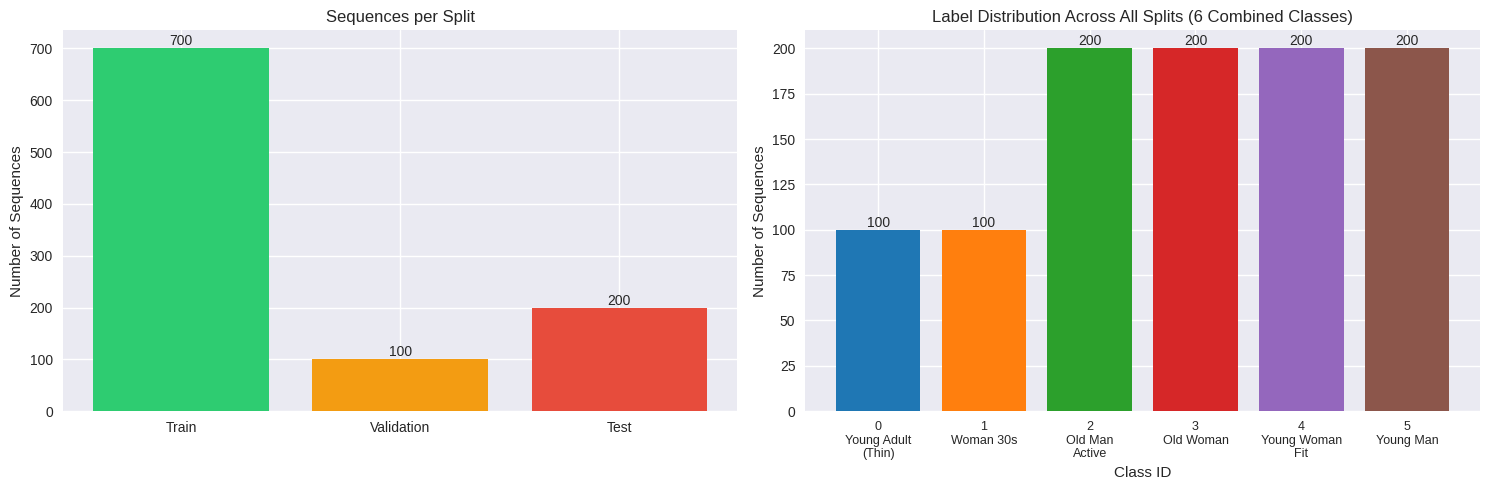

In [7]:
# Generate temporal sequences with FPS sampling
print("\nGenerating temporal sequences...")
print("="*60)

# Generate training set
print("\n1. Training set:")
X_train, y_train = generate_dataset(
    train_scans,
    scans_dir,
    num_sequences_per_scan=10,
    num_frames=30,
    num_points=200,
    verbose=True
)

# Generate validation set
print("\n2. Validation set:")
X_val, y_val = generate_dataset(
    val_scans,
    scans_dir,
    num_sequences_per_scan=10,
    num_frames=30,
    num_points=200,
    verbose=True
)

# Generate test set
print("\n3. Test set:")
X_test, y_test = generate_dataset(
    test_scans,
    scans_dir,
    num_sequences_per_scan=10,
    num_frames=30,
    num_points=200,
    verbose=True
)

print("\n" + "="*60)
print("Dataset Summary:")
print("="*60)
print(f"Training: {X_train.shape} - {len(np.unique(y_train))} classes")
print(f"Validation: {X_val.shape} - {len(np.unique(y_val))} classes")
print(f"Test: {X_test.shape} - {len(np.unique(y_test))} classes")
print("="*60)

# Validate that all 6 classes are present
all_labels = np.concatenate([y_train, y_val, y_test])
unique_labels = sorted(np.unique(all_labels))
expected_classes = list(range(6))

if set(unique_labels) != set(expected_classes):
    print(f"\n⚠️  WARNING: Missing classes! Expected {expected_classes}, got {unique_labels}")
else:
    print(f"\n✓ All 6 classes present: {unique_labels}")

# Convert labels to one-hot encoding
num_classes = 6
y_train_onehot = to_categorical(y_train, num_classes)
y_val_onehot = to_categorical(y_val, num_classes)
y_test_onehot = to_categorical(y_test, num_classes)

print(f"\n✓ Labels converted to one-hot encoding")
print(f"  Train: {y_train_onehot.shape}, Val: {y_val_onehot.shape}, Test: {y_test_onehot.shape}")

# Visualize dataset statistics
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sequence count by split
split_names = ['Train', 'Validation', 'Test']
split_counts = [len(X_train), len(X_val), len(X_test)]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[0].bar(split_names, split_counts, color=colors)
axes[0].set_ylabel('Number of Sequences')
axes[0].set_title('Sequences per Split')
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

# Label distribution (6 combined classes)
all_labels = np.concatenate([y_train, y_val, y_test])
unique, counts = np.unique(all_labels, return_counts=True)

class_names = [
    'Young Adult\n(Thin)',
    'Woman 30s',
    'Old Man\nActive',
    'Old Woman',
    'Young Woman\nFit',
    'Young Man'
]

bars = axes[1].bar(unique, counts, color=plt.cm.tab10(unique))
axes[1].set_xlabel('Class ID')
axes[1].set_ylabel('Number of Sequences')
axes[1].set_title('Label Distribution (6 Combined Classes)')
axes[1].set_xticks(unique)
axes[1].set_xticklabels([f'{i}\n{class_names[i]}' for i in unique], rotation=0, ha='center', fontsize=9)
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


## Phase 2: Model Architecture & Training


### Train Model

In [ ]:
# 1. Reload modules to get latest changes (important after code updates)
import importlib
import src.train
importlib.reload(src.train)
from src.train import train_model, setup_callbacks
print("✓ Modules reloaded")

# 2. Clear GPU memory
tf.keras.backend.clear_session()
gc.collect()

# 3. Enable mixed precision BEFORE building model
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print("✓ Mixed precision enabled")

# 4. Build model (will use mixed precision automatically)
# Input shape: (30, 200, 5) - channels: (x, y, z, velocity, snr)
# Note: Using 6 combined classes (10 original subjects mapped to 6 classes)
model = build_mmidnet(input_shape=(30, 200, 5), num_classes=6)
print("✓ Model built with mixed precision (6 classes)")

# Show model summary
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\n✓ Total parameters: {total_params:,}")

# 5. Use train_model function (handles compilation with improved settings)
# Note: train_model now includes class weights, label smoothing, gradient clipping, and reduced LR
history = train_model(
    model, 
    X_train, y_train_onehot, 
    X_val, y_val_onehot,
    epochs=150,
    batch_size=32,
    checkpoint_dir=checkpoint_dir,
    use_class_weights=True  # Enable class weights to help with collapsed classes
)

# 6. Save history
import pickle
os.makedirs(results_dir, exist_ok=True)
with open(os.path.join(results_dir, 'training_history.pkl'), 'wb') as f:
    pickle.dump(history.history, f)

print("\n✓ Training complete!")

✓ Modules reloaded
✓ Mixed precision enabled
✓ Model built with mixed precision (6 classes)


Model: "MMIDNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30, 200,   │          0 │ -                 │
│                     │ 5)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 30, 200,   │          0 │ input[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transform_block_td… │ (None, 30, 3, 3)  │     85,897 │ get_item[0][0]    │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transform_block_ap… │ (None, 30, 200,   │          0 │ get_item[0][0],   │
│ (Lambda)            │ 3)                │            │ transform_block_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 30, 200,   │          0 │ input[0][0]       │
│ (GetItem)           │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transform_block_co… │ (None, 30, 200,   │          0 │ transform_block_… │
│ (Concatenate)       │ 5)                │            │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_cnn_td1a   │ (None, 30, 200,   │        384 │ transform_block_… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_cnn_td_bn… │ (None, 30, 200,   │        256 │ residual_cnn_td1… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_cnn_td_dr… │ (None, 30, 200,   │          0 │ residual_cnn_td_… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_cnn_td1b   │ (None, 30, 200,   │      4,160 │ residual_cnn_td_… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_cnn_td_bn… │ (None, 30, 200,   │        256 │ residual_cnn_td1… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_cnn_td_sk… │ (None, 30, 200,   │        384 │ transform_block_… │
│ (TimeDistributed)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_cnn_add1   │ (None, 30, 200,   │          0 │ residual_cnn_td_… │
│ (Add)               │ 64)               │            │ residual_cnn_td_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_cnn_relu1  │ (None, 30, 200,   │          0 │ residual_cnn_add… │
│ (ReLU)              │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_cnn_td2a   │ (None, 30, 200,   │      8,320 │ residual_cnn_rel… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_cnn_td_bn… │ (None, 30, 200,   │        512 │ residual_cnn_td2… │
│ (TimeDistributed)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual_cnn_td_dr… │ (None, 30, 200,   │          0 │ residual_cnn_td_

 Total params: 915,984 (3.49 MB)

 Trainable params: 911,632 (3.48 MB)

...

22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.4647 - loss: 2.0169 - val_accuracy: 0.4600 - val_loss: 2.2147 - learning_rate: 2.5000e-04
Epoch 21/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4795 - loss: 2.0435
Epoch 21: val_accuracy did not improve from 0.46000
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.4790 - loss: 2.0427 - val_accuracy: 0.4000 - val_loss: 2.1806 - learning_rate: 2.5000e-04
Epoch 22/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4757 - loss: 2.0249
Epoch 22: val_accuracy did not improve from 0.46000
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.4764 - loss: 2.0233 - val_accuracy: 0.3900 - val_loss: 2.3785 - learning_rate: 2.5000e-04
Epoch 23/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4659 - loss: 1.9547
Epoch 23: val_accuracy improved from 0.46000 to 0.48000, saving model to /content/drive/MyDrive/Arqaios/checkpoints/best_model.h5


22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.4678 - loss: 1.9528 - val_accuracy: 0.4800 - val_loss: 2.1756 - learning_rate: 2.5000e-04
Epoch 24/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5477 - loss: 1.8129
Epoch 24: val_accuracy improved from 0.48000 to 0.49000, saving model to /content/drive/MyDrive/Arqaios/checkpoints/best_model.h5


22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.5464 - loss: 1.8156 - val_accuracy: 0.4900 - val_loss: 2.1535 - learning_rate: 2.5000e-04
Epoch 25/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5360 - loss: 1.8970
Epoch 25: val_accuracy did not improve from 0.49000
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.5360 - loss: 1.8960 - val_accuracy: 0.4700 - val_loss: 2.2135 - learning_rate: 2.5000e-04
Epoch 26/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5665 - loss: 1.8819
Epoch 26: val_accuracy did not improve from 0.49000
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.5663 - loss: 1.8815 - val_accuracy: 0.4800 - val_loss: 2.2026 - learning_rate: 2.5000e-04
Epoch 27/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5740 - loss: 1.8639
Epoch 27: val_accuracy did not improve from 0.49000
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5740 - loss: 1.8629 - val_accuracy: 0.4500 - val_loss: 2.1596 - learning_rate: 2.5000e-04
Epoch 28/150
22/2

22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.6364 - loss: 1.7459 - val_accuracy: 0.6300 - val_loss: 2.2351 - learning_rate: 1.2500e-04
Epoch 32/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6146 - loss: 1.7610
Epoch 32: val_accuracy did not improve from 0.63000
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6159 - loss: 1.7603 - val_accuracy: 0.5800 - val_loss: 2.1951 - learning_rate: 1.2500e-04
Epoch 33/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7075 - loss: 1.6579
Epoch 33: val_accuracy did not improve from 0.63000
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7076 - loss: 1.6572 - val_accuracy: 0.5300 - val_loss: 2.3259 - learning_rate: 1.2500e-04
Epoch 34/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7021 - loss: 1.6638
Epoch 34: val_accuracy did not improve from 0.63000

Epoch 34: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.7012 - loss: 1.6644 - val_accu

22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.7417 - loss: 1.5923 - val_accuracy: 0.6400 - val_loss: 1.9869 - learning_rate: 6.2500e-05
Epoch 38/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7655 - loss: 1.5886
Epoch 38: val_accuracy did not improve from 0.64000
22/22 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.7657 - loss: 1.5877 - val_accuracy: 0.5500 - val_loss: 2.2202 - learning_rate: 6.2500e-05
Epoch 39/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7613 - loss: 1.5597
Epoch 39: val_accuracy did not improve from 0.64000
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.7608 - loss: 1.5601 - val_accuracy: 0.5200 - val_loss: 2.3019 - learning_rate: 6.2500e-05
Epoch 40/150
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7203 - loss: 1.6239
Epoch 40: val_accuracy did not improve from 0.64000
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.7214 - loss: 1.6218 - val_accuracy: 0.5900 - val_loss: 2.1692 - learning_rate: 6.2500e-05
Epoch 41/150
22/2

### Visualize Training Progress


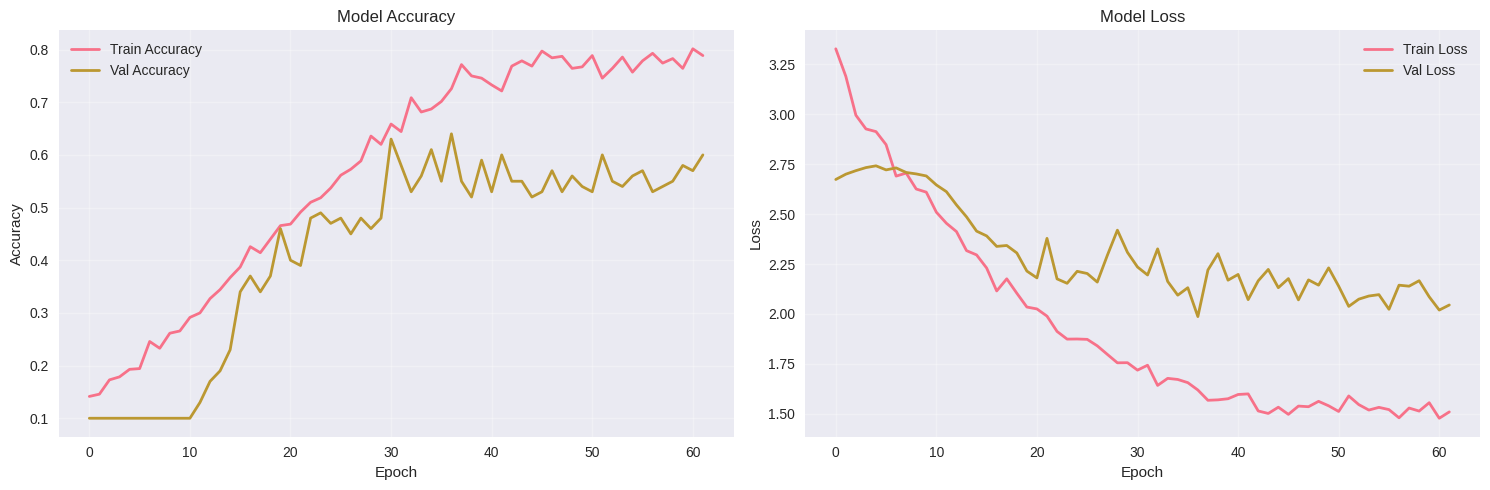


Best validation accuracy: 0.6400 at epoch 37
Best validation loss: 1.9869


In [9]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print best values
best_epoch = np.argmax(history.history['val_accuracy'])
print(f"\nBest validation accuracy: {history.history['val_accuracy'][best_epoch]:.4f} at epoch {best_epoch+1}")
print(f"Best validation loss: {min(history.history['val_loss']):.4f}")


## Phase 3: Evaluation & Results


In [10]:
# Load best model (uses checkpoint_dir from cell 2)
checkpoint_path = os.path.join(checkpoint_dir, 'best_model.h5')

if os.path.exists(checkpoint_path):
    model.load_weights(checkpoint_path)
    print(f"✓ Loaded best model weights from: {checkpoint_path}")
else:
    print(f"✗ Model checkpoint not found: {checkpoint_path}")
    print("  Training may not have completed yet")

# Standard evaluation
test_loss, test_accuracy, y_pred, y_pred_classes, y_true_classes = evaluate_model(
    model, X_test, y_test_onehot
)

print(f"\nStandard Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

# Sliding window evaluation
sw_accuracy, sw_predictions, sw_y_pred, sw_y_true = evaluate_with_sliding_window(
    model, X_test, y_test_onehot, num_variations=5
)

print(f"\nSliding Window Test Accuracy: {sw_accuracy:.4f} ({sw_accuracy*100:.2f}%)")
print(f"Improvement: {(sw_accuracy - test_accuracy)*100:.2f}%")


✓ Loaded best model weights from: /content/drive/MyDrive/Arqaios/checkpoints/best_model.h5

Standard Test Accuracy: 0.7000 (70.00%)
Test Loss: 1.7408
Evaluating with sliding window...
  Processed 20/200 sequences
  Processed 40/200 sequences
  Processed 60/200 sequences
  Processed 80/200 sequences
  Processed 100/200 sequences
  Processed 120/200 sequences
  Processed 140/200 sequences
  Processed 160/200 sequences
  Processed 180/200 sequences
  Processed 200/200 sequences

Sliding Window Test Accuracy: 0.7000 (70.00%)
Improvement: 0.00%


### Per-Class Accuracy


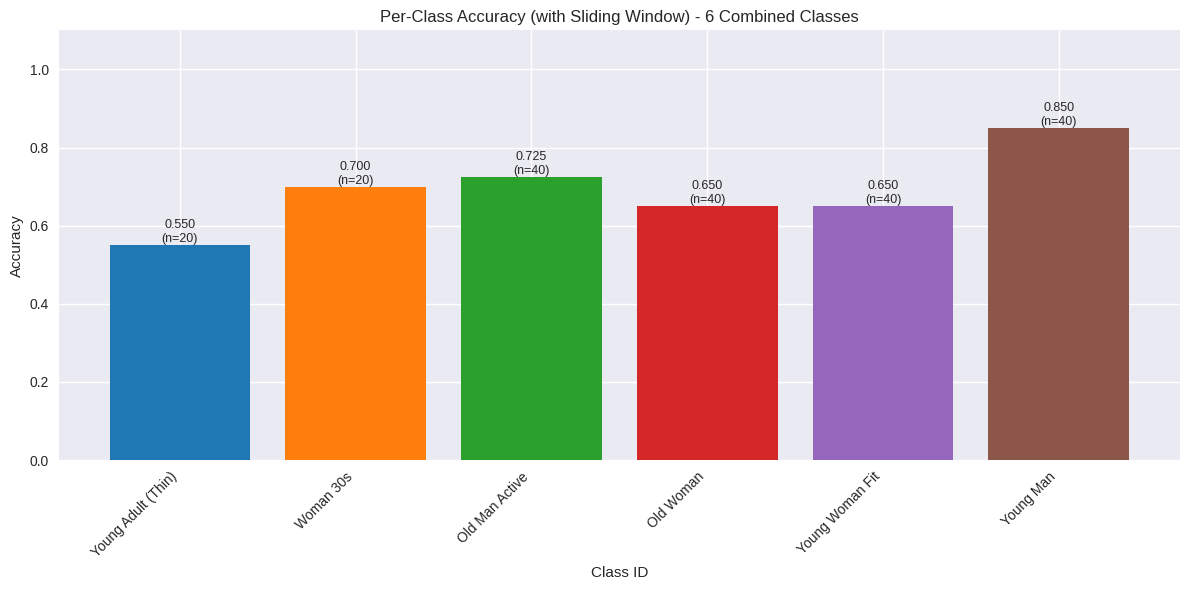


Per-class Accuracy (6 Combined Classes):
------------------------------------------------------------
Class 0 (Young Adult (Thin)): 0.5500 (55.00%) - 20 samples
Class 1 (Woman 30s): 0.7000 (70.00%) - 20 samples
Class 2 (Old Man Active): 0.7250 (72.50%) - 40 samples
Class 3 (Old Woman): 0.6500 (65.00%) - 40 samples
Class 4 (Young Woman Fit): 0.6500 (65.00%) - 40 samples
Class 5 (Young Man): 0.8500 (85.00%) - 40 samples


In [11]:
# Per-class accuracy with sliding window
# Note: Using 6 combined classes
class_names = [
    'Young Adult (Thin)',      # 0
    'Woman 30s',              # 1
    'Old Man Active',          # 2
    'Old Woman',               # 3
    'Young Woman Fit',         # 4
    'Young Man'                # 5
]

per_class_acc = get_per_class_accuracy(sw_y_true, sw_y_pred, num_classes=6)

fig, ax = plt.subplots(figsize=(12, 6))
subjects = list(per_class_acc.keys())
accuracies = [per_class_acc[s]['accuracy'] for s in subjects]
counts = [per_class_acc[s]['count'] for s in subjects]

bars = ax.bar(subjects, accuracies, color=plt.cm.tab10(subjects))
ax.set_xlabel('Class ID')
ax.set_ylabel('Accuracy')
ax.set_title('Per-Class Accuracy (with Sliding Window) - 6 Combined Classes')
ax.set_ylim([0, 1.1])
ax.set_xticks(subjects)
ax.set_xticklabels([class_names[i] for i in subjects], rotation=45, ha='right')

for i, (bar, acc, count) in enumerate(zip(bars, accuracies, counts)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.3f}\n(n={count})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\nPer-class Accuracy (6 Combined Classes):")
print("-" * 60)
for subj_id in sorted(per_class_acc.keys()):
    acc = per_class_acc[subj_id]['accuracy']
    count = per_class_acc[subj_id]['count']
    print(f"Class {subj_id} ({class_names[subj_id]}): {acc:.4f} ({acc*100:.2f}%) - {count} samples")


### Confusion Matrix


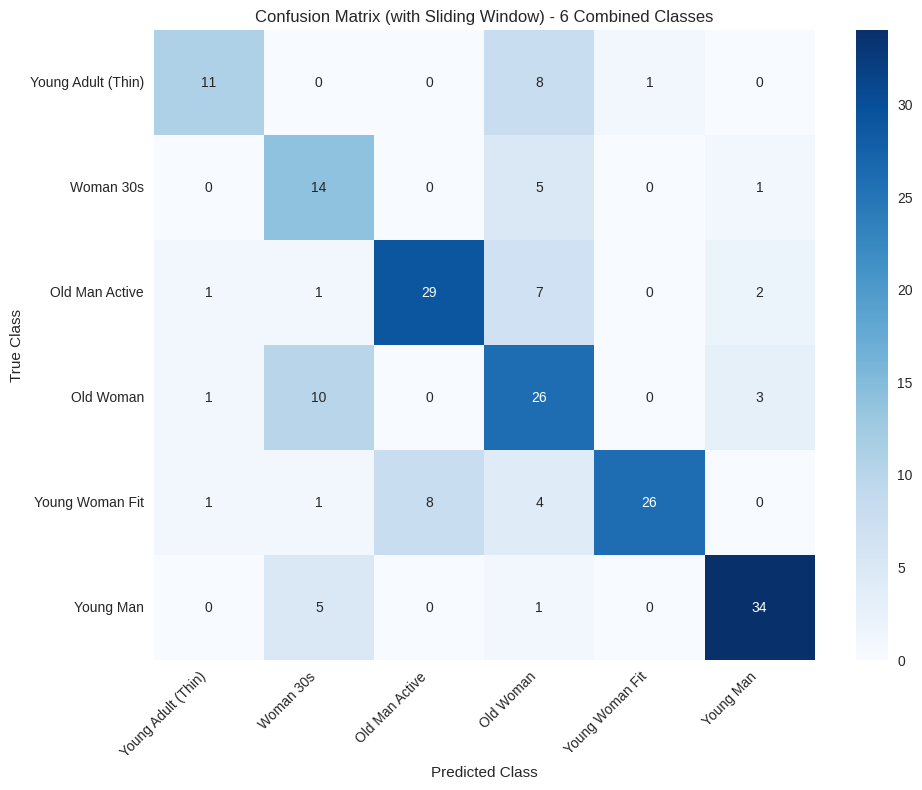


Classification Report (6 Combined Classes):
                    precision    recall  f1-score   support

Young Adult (Thin)       0.79      0.55      0.65        20
         Woman 30s       0.45      0.70      0.55        20
    Old Man Active       0.78      0.72      0.75        40
         Old Woman       0.51      0.65      0.57        40
   Young Woman Fit       0.96      0.65      0.78        40
         Young Man       0.85      0.85      0.85        40

          accuracy                           0.70       200
         macro avg       0.72      0.69      0.69       200
      weighted avg       0.75      0.70      0.71       200



In [12]:
# Confusion matrix (6 combined classes)
class_names = [
    'Young Adult (Thin)',      # 0
    'Woman 30s',              # 1
    'Old Man Active',          # 2
    'Old Woman',               # 3
    'Young Woman Fit',         # 4
    'Young Man'                # 5
]

cm = confusion_matrix(sw_y_true, sw_y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_names[i] for i in range(6)],
            yticklabels=[class_names[i] for i in range(6)])
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix (with Sliding Window) - 6 Combined Classes')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Classification report
from sklearn.metrics import classification_report
print("\nClassification Report (6 Combined Classes):")
print(classification_report(sw_y_true, sw_y_pred,
                          target_names=class_names))


### Final Results Summary


In [13]:
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(f"Standard Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Sliding Window Test Accuracy: {sw_accuracy:.4f} ({sw_accuracy*100:.2f}%)")
print(f"Improvement: {(sw_accuracy - test_accuracy)*100:.2f}%")
print(f"\nDataset:")
print(f"  Training sequences: {len(X_train)}")
print(f"  Validation sequences: {len(X_val)}")
print(f"  Test sequences: {len(X_test)}")
print(f"\nModel Architecture: MMIDNet")
print(f"  - Transform Block (T-Net)")
print(f"  - Residual CNN Block")
print(f"  - Global Max Pooling")
print(f"  - Bi-LSTM Block")
print(f"  - Dense Block")
print(f"  - Total parameters: {model.count_params():,}")
print("="*60)



FINAL RESULTS SUMMARY
Standard Test Accuracy: 0.7000 (70.00%)
Sliding Window Test Accuracy: 0.7000 (70.00%)
Improvement: 0.00%

Dataset:
  Training sequences: 700
  Validation sequences: 100
  Test sequences: 200

Model Architecture: MMIDNet
  - Transform Block (T-Net)
  - Residual CNN Block
  - Global Max Pooling
  - Bi-LSTM Block
  - Dense Block
  - Total parameters: 915,984
